<a href="https://colab.research.google.com/github/JabulaniMcineka/MyProjects/blob/main/ExposureReport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()   # select BOTH files again






Saving S3E-UnexposedCopy_DATA_LABELS_2026-02-16_0759.csv to S3E-UnexposedCopy_DATA_LABELS_2026-02-16_0759 (1).csv
Saving S3E-ExposedCopy_DATA_LABELS_2026-02-16_0758.csv to S3E-ExposedCopy_DATA_LABELS_2026-02-16_0758 (1).csv


In [ ]:
file_names = list(uploaded.keys())
print(file_names)
print("Number of files:", len(file_names))



['S3E-UnexposedCopy_DATA_LABELS_2026-02-16_0759 (1).csv', 'S3E-ExposedCopy_DATA_LABELS_2026-02-16_0758 (1).csv']
Number of files: 2


In [ ]:
print(df1.dtypes)
print(df2.dtypes)


Record ID               object
Event Name              object
Participant's Gender    object
Nearest clinic          object
Participant's Age        int64
Age group               object
dtype: object
Record ID               object
Event Name              object
Participant's Gender    object
Nearest clinic          object
Participant's Age        int64
Age group               object
dtype: object


In [ ]:
df1["Exposure Group"] = "Unexposed"
df2["Exposure Group"] = "Exposed"

df = pd.concat([df1, df2], ignore_index=True)


In [ ]:
df["Exposure Group"].value_counts()


,count
Exposure Group,
Exposed,161
Unexposed,84


In [ ]:
gender_counts = (
    df.groupby(["Exposure Group", "Participant's Gender"])
      .size()
      .unstack(fill_value=0)
)


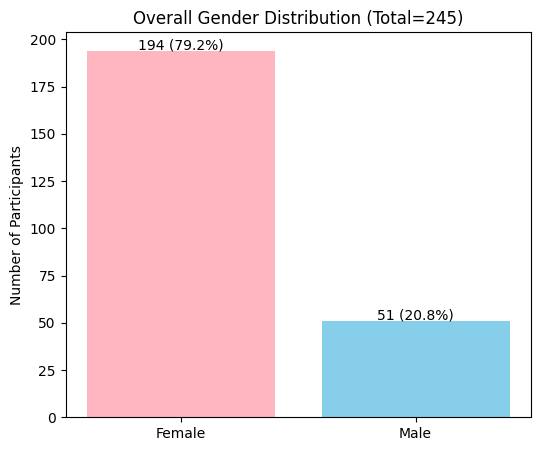

In [ ]:
import matplotlib.pyplot as plt

# Count gender
gender_counts = df["Participant's Gender"].value_counts()
total_participants = gender_counts.sum()

# Define colors: pink for Female, skyblue for Male
colors = ['lightpink' if gender=='Female' else 'skyblue' for gender in gender_counts.index]

# Plot
plt.figure(figsize=(6,5))
plt.bar(gender_counts.index, gender_counts.values, color=colors)
plt.title(f'Overall Gender Distribution (Total={total_participants})')
plt.ylabel('Number of Participants')

# Add counts and percentages
for i, v in enumerate(gender_counts.values):
    pct = v / total_participants * 100
    plt.text(i, v + 0.5, f"{v} ({pct:.1f}%)", ha='center')

plt.show()



In [ ]:
df["Exposure Group"] = df["Event Name"].str.extract(r'(Exposed|Unexposed)')


summary = (
    df.groupby(["Exposure Group", "Participant's Gender"])
      .size()
      .unstack(fill_value=0)
)



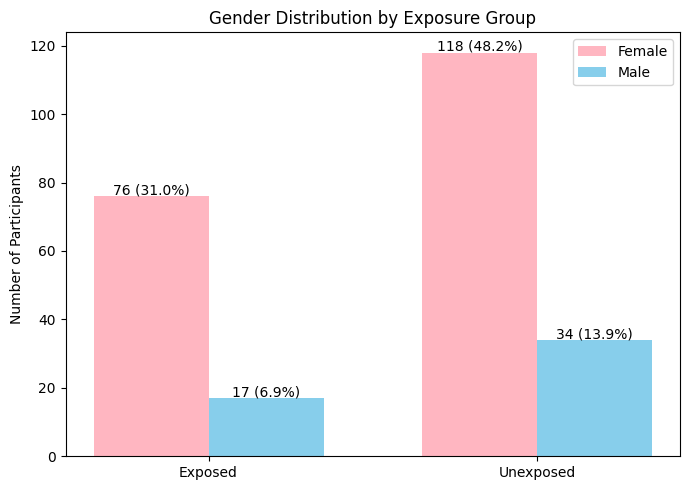

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

groups = summary.index  # Exposed / Unexposed
genders = summary.columns  # Female / Male
x = np.arange(len(groups))  # positions for groups
width = 0.35

plt.figure(figsize=(7,5))

# Bars
plt.bar(x - width/2, summary["Female"], width, label="Female", color='lightpink')
plt.bar(x + width/2, summary["Male"], width, label="Male", color='skyblue')

# Labels
plt.xticks(x, groups)
plt.ylabel("Number of Participants")
plt.title("Gender Distribution by Exposure Group")
plt.legend()

# Add counts and percentages
total = summary.sum().sum()  # overall total
for i, group in enumerate(groups):
    for j, gender in enumerate(genders):
        value = summary.loc[group, gender]
        pct = value / total * 100
        offset = -width/2 if gender == "Female" else width/2
        plt.text(x[i] + offset, value + 0.5, f"{value} ({pct:.1f}%)", ha="center")

plt.tight_layout()
plt.show()


In [ ]:
# Ensure Exposure Group exists
df["Exposure Group"] = df["Event Name"].str.extract(r'(Exposed|Unexposed)')

# Create filtered datasets
df_exposed = df[df["Exposure Group"] == "Exposed"]
df_unexposed = df[df["Exposure Group"] == "Unexposed"]  # <- this line was missing



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_age_gender_counts(df_group):
    age_gender = df_group.groupby(["Age group", "Participant's Gender"]).size().unstack(fill_value=0)
    age_groups = age_gender.index
    male_counts = age_gender["Male"] if "Male" in age_gender.columns else np.zeros(len(age_groups))
    female_counts = age_gender["Female"] if "Female" in age_gender.columns else np.zeros(len(age_groups))
    return age_groups, male_counts, female_counts

age_groups_exp, male_exp, female_exp = get_age_gender_counts(df_exposed)
age_groups_unexp, male_unexp, female_unexp = get_age_gender_counts(df_unexposed)


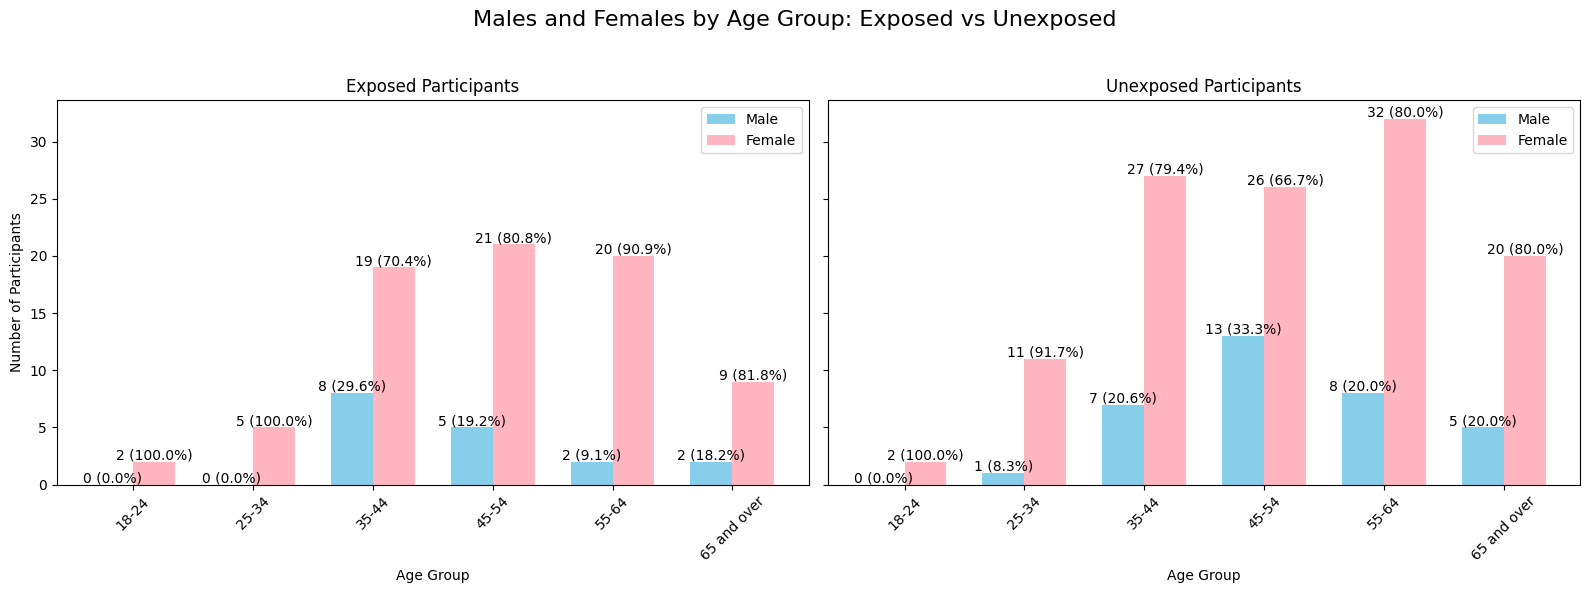

In [ ]:
width = 0.35
x_exp = np.arange(len(age_groups_exp))
x_unexp = np.arange(len(age_groups_unexp))

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Exposed plot
axes[0].bar(x_exp - width/2, male_exp, width, label="Male", color='skyblue')
axes[0].bar(x_exp + width/2, female_exp, width, label="Female", color='lightpink')
axes[0].set_xticks(x_exp)
axes[0].set_xticklabels(age_groups_exp, rotation=45)
axes[0].set_title("Exposed Participants")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Participants")
axes[0].legend()

# Add counts on top
for i in range(len(age_groups_exp)):
    total = male_exp.iloc[i] + female_exp.iloc[i]
    if total > 0:
        axes[0].text(x_exp[i] - width/2, male_exp.iloc[i] + 0.2,
                     f"{male_exp.iloc[i]} ({male_exp.iloc[i]/total*100:.1f}%)",
                     ha='center')
        axes[0].text(x_exp[i] + width/2, female_exp.iloc[i] + 0.2,
                     f"{female_exp.iloc[i]} ({female_exp.iloc[i]/total*100:.1f}%)",
                     ha='center')

# Unexposed plot
axes[1].bar(x_unexp - width/2, male_unexp, width, label="Male", color='skyblue')
axes[1].bar(x_unexp + width/2, female_unexp, width, label="Female", color='lightpink')
axes[1].set_xticks(x_unexp)
axes[1].set_xticklabels(age_groups_unexp, rotation=45)
axes[1].set_title("Unexposed Participants")
axes[1].set_xlabel("Age Group")
axes[1].legend()

# Add counts on top
for i in range(len(age_groups_unexp)):
    total = male_unexp.iloc[i] + female_unexp.iloc[i]
    if total > 0:
        axes[1].text(x_unexp[i] - width/2, male_unexp.iloc[i] + 0.2,
                     f"{male_unexp.iloc[i]} ({male_unexp.iloc[i]/total*100:.1f}%)",
                     ha='center')
        axes[1].text(x_unexp[i] + width/2, female_unexp.iloc[i] + 0.2,
                     f"{female_unexp.iloc[i]} ({female_unexp.iloc[i]/total*100:.1f}%)",
                     ha='center')

plt.suptitle("Males and Females by Age Group: Exposed vs Unexposed", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import numpy as np

# Create age-gender table
age_gender = (
    df.groupby(["Age group", "Participant's Gender"])
      .size()
      .unstack(fill_value=0)
)

# Extract counts safely
age_groups = age_gender.index

male_counts = age_gender["Male"] if "Male" in age_gender.columns else np.zeros(len(age_gender))
female_counts = age_gender["Female"] if "Female" in age_gender.columns else np.zeros(len(age_gender))

x = np.arange(len(age_groups))
width = 0.35


/tmp/ipython-input-3563106549.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  male_val = male_counts[i] if hasattr(male_counts, "__getitem__") else male_counts.iloc[i]
/tmp/ipython-input-3563106549.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  female_val = female_counts[i] if hasattr(female_counts, "__getitem__") else female_counts.iloc[i]


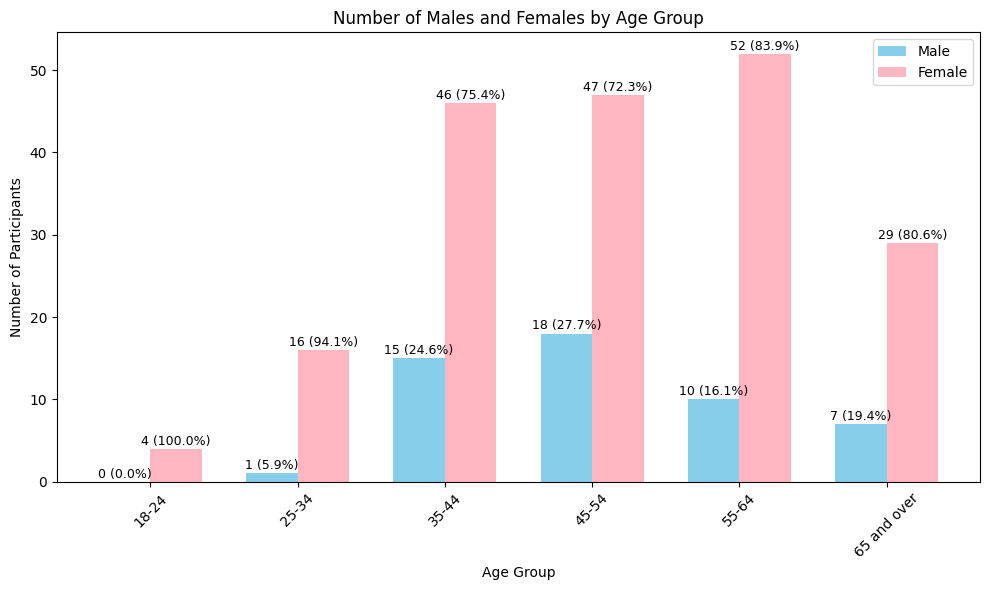

In [ ]:
plt.figure(figsize=(10,6))

# Plot bars
plt.bar(x - width/2, male_counts, width, label="Male", color='skyblue')
plt.bar(x + width/2, female_counts, width, label="Female", color='lightpink')

plt.xlabel("Age Group")
plt.ylabel("Number of Participants")
plt.title("Number of Males and Females by Age Group")
plt.xticks(x, age_groups, rotation=45)
plt.legend()

# Add counts + percentages
for i in range(len(age_groups)):

    male_val = male_counts[i] if hasattr(male_counts, "__getitem__") else male_counts.iloc[i]
    female_val = female_counts[i] if hasattr(female_counts, "__getitem__") else female_counts.iloc[i]

    total = male_val + female_val

    if total > 0:
        plt.text(x[i] - width/2, male_val + 0.5,
                 f"{male_val} ({male_val/total*100:.1f}%)",
                 ha='center', fontsize=9)

        plt.text(x[i] + width/2, female_val + 0.5,
                 f"{female_val} ({female_val/total*100:.1f}%)",
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()



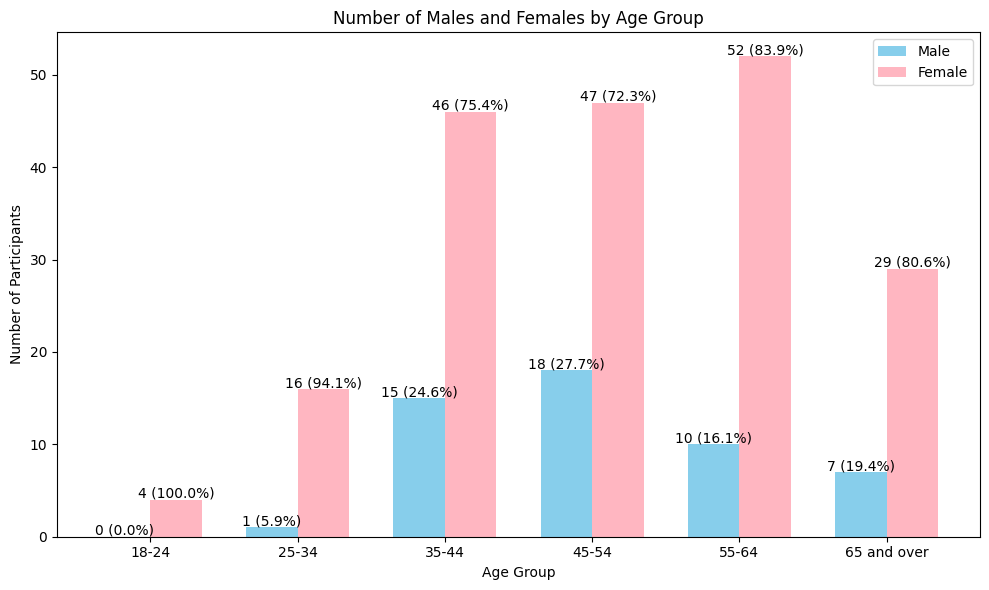

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Group using correct column names
age_gender = (
    df.groupby(["Age group", "Participant's Gender"])
      .size()
      .unstack(fill_value=0)
)

# Prepare data
age_groups = age_gender.index
male_counts = age_gender["Male"] if "Male" in age_gender.columns else np.zeros(len(age_gender))
female_counts = age_gender["Female"] if "Female" in age_gender.columns else np.zeros(len(age_gender))

x = np.arange(len(age_groups))
width = 0.35

plt.figure(figsize=(10,6))

bars_male = plt.bar(x - width/2, male_counts, width, label='Male', color='skyblue')
bars_female = plt.bar(x + width/2, female_counts, width, label='Female', color='lightpink')

plt.xlabel('Age Group')
plt.ylabel('Number of Participants')
plt.title('Number of Males and Females by Age Group')
plt.xticks(x, age_groups)
plt.legend()

# Add labels
for i in range(len(age_groups)):
    total = male_counts.iloc[i] + female_counts.iloc[i]
    if total > 0:
        plt.text(x[i] - width/2, male_counts.iloc[i] + 0.2,
                 f"{male_counts.iloc[i]} ({male_counts.iloc[i]/total*100:.1f}%)",
                 ha='center')
        plt.text(x[i] + width/2, female_counts.iloc[i] + 0.2,
                 f"{female_counts.iloc[i]} ({female_counts.iloc[i]/total*100:.1f}%)",
                 ha='center')

plt.tight_layout()
plt.show()






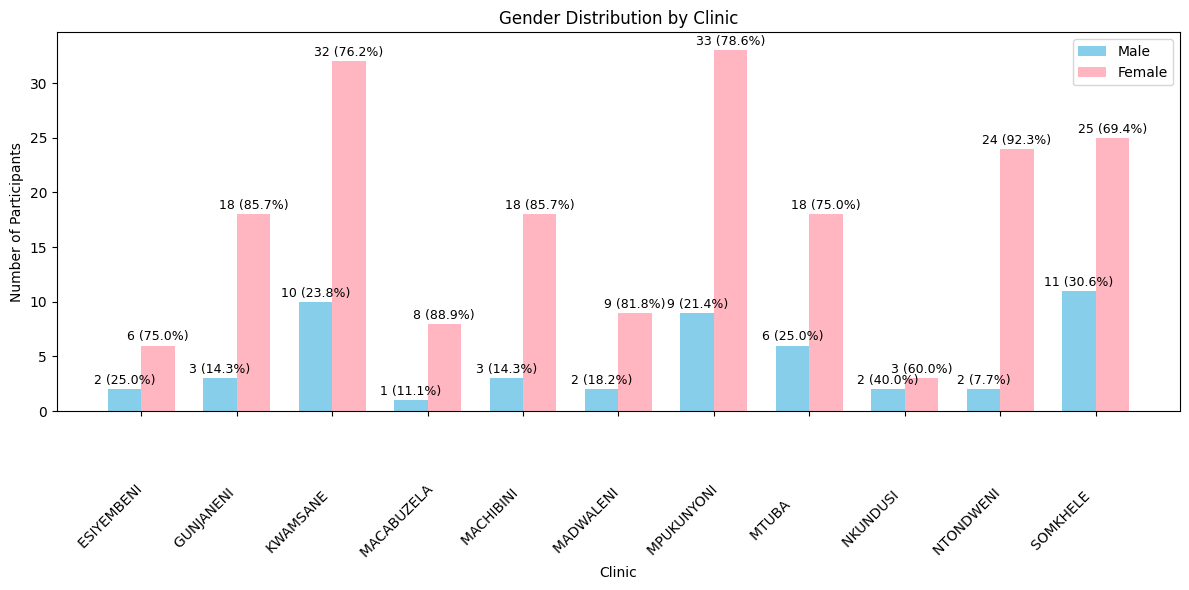

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Group by Clinic and Participant's Gender
clinic_gender = df.groupby(["Nearest clinic", "Participant's Gender"], observed=True).size().unstack(fill_value=0)

x = np.arange(len(clinic_gender))
width = 0.35

plt.figure(figsize=(12,6))

# Bars
bars_male = plt.bar(x - width/2, clinic_gender.get('Male', pd.Series(np.zeros(len(clinic_gender)))).iloc[:], width, color='skyblue', label='Male')
bars_female = plt.bar(x + width/2, clinic_gender.get('Female', pd.Series(np.zeros(len(clinic_gender)))).iloc[:], width, color='lightpink', label='Female')

plt.xlabel("Clinic")
plt.ylabel("Number of Participants")
plt.title("Gender Distribution by Clinic")
plt.xticks(x, clinic_gender.index, rotation=45)
plt.legend()

# Add counts + percentages
for i in range(len(clinic_gender)):
    male_count = clinic_gender.get('Male', pd.Series(np.zeros(len(clinic_gender)))).iloc[i]
    female_count = clinic_gender.get('Female', pd.Series(np.zeros(len(clinic_gender)))).iloc[i]
    total = male_count + female_count
    if total > 0:
        plt.text(x[i] - width/2, male_count + 0.2,
                 f"{int(male_count)} ({male_count/total*100:.1f}%)",
                 ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + width/2, female_count + 0.2,
                 f"{int(female_count)} ({female_count/total*100:.1f}%)",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


['Unexposed' 'Exposed']


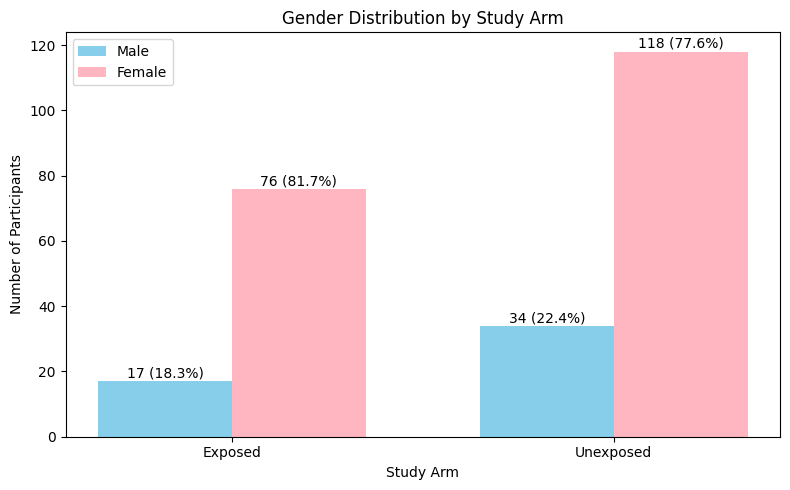

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Create 'Arm' column from Event Name
# -------------------------------
# Adjust the regex if your Event Names include different patterns
df["Arm"] = df["Event Name"].str.extract(r'(Exposed|Unexposed|Arm 1|Arm 2|Arm 3)')

# Check that the new column looks correct
print(df["Arm"].unique())

# -------------------------------
# 2️⃣ Group by Arm and Participant's Gender
# -------------------------------
arm_gender = df.groupby(["Arm", "Participant's Gender"], observed=True).size().unstack(fill_value=0)

x = np.arange(len(arm_gender))
width = 0.35

plt.figure(figsize=(8,5))

# Bars with safe defaults
bars_male = plt.bar(
    x - width/2,
    arm_gender.get('Male', pd.Series(np.zeros(len(arm_gender)))).iloc[:],
    width, color='skyblue', label='Male'
)
bars_female = plt.bar(
    x + width/2,
    arm_gender.get('Female', pd.Series(np.zeros(len(arm_gender)))).iloc[:],
    width, color='lightpink', label='Female'
)

plt.xlabel('Study Arm')
plt.ylabel('Number of Participants')
plt.title('Gender Distribution by Study Arm')
plt.xticks(x, arm_gender.index)
plt.legend()

# Add counts and percentages on top
for i in range(len(arm_gender)):
    male_count = arm_gender.get('Male', pd.Series(np.zeros(len(arm_gender)))).iloc[i]
    female_count = arm_gender.get('Female', pd.Series(np.zeros(len(arm_gender)))).iloc[i]
    total = male_count + female_count
    if total > 0:
        plt.text(x[i] - width/2, male_count + 0.2,
                 f"{int(male_count)} ({male_count/total*100:.1f}%)",
                 ha='center', va='bottom', fontsize=10)
        plt.text(x[i] + width/2, female_count + 0.2,
                 f"{int(female_count)} ({female_count/total*100:.1f}%)",
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()




In [ ]:
!pip install python-docx



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Inches
import io

